# SVM

## Importar Dados

In [1]:
import pandas as pd
caminho = '../'

X_test = pd.read_csv(caminho + 'database/processed/splitted/X_test.csv')
X_train = pd.read_csv(caminho + 'database/processed/splitted/X_train.csv')
y_test = pd.read_csv(caminho + 'database/processed/splitted/y_test.csv')
y_train = pd.read_csv(caminho + 'database/processed/splitted/y_train.csv')

## SVM - Default

In [2]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', probability=True, random_state=14)
svm.fit(X_train, y_train)

c:\Users\renan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


=== MÉTRICAS DE DESEMPENHO (KNN DEFAULT) ===

Acurácia: 0.8018
Precisão: 0.7846
Recall: 0.7450
F1-Score: 0.7585
MCC: 0.5282
AUC: 0.8537
--------------------------------------------------


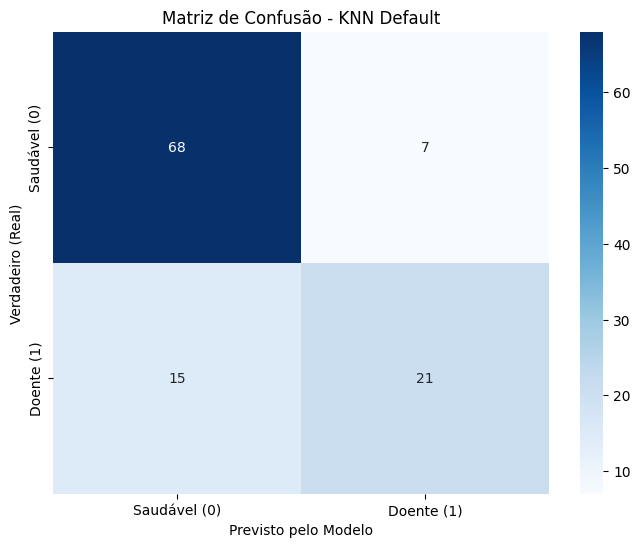

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             matthews_corrcoef, confusion_matrix)

# Fazendo as Previsões no conjunto de teste
y_pred_def = svm.predict(X_test)
y_prob_def = svm.predict_proba(X_test)[:, 1]

# Métricas
acuracia_def = accuracy_score(y_test, y_pred_def)
precisao_def = precision_score(y_test, y_pred_def, average='macro', zero_division=0)
recall_def = recall_score(y_test, y_pred_def, average='macro', zero_division=0)
f1_def = f1_score(y_test, y_pred_def, average='macro', zero_division=0)
mcc_def = matthews_corrcoef(y_test, y_pred_def)
auc = roc_auc_score(y_test, y_prob_def)

# Exibindo os Resultados
print("=== MÉTRICAS DE DESEMPENHO (KNN DEFAULT) ===\n")
print(f"Acurácia: {acuracia_def:.4f}")
print(f"Precisão: {precisao_def:.4f}")
print(f"Recall: {recall_def:.4f}")
print(f"F1-Score: {f1_def:.4f}")
print(f"MCC: {mcc_def:.4f}")
print(f"AUC: {auc:.4f}")
print("-" * 50)

# Plotando a Matriz de Confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_def)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Saudável (0)', 'Doente (1)'],
            yticklabels=['Saudável (0)', 'Doente (1)'])
plt.title('Matriz de Confusão - KNN Default')
plt.xlabel('Previsto pelo Modelo')
plt.ylabel('Verdadeiro (Real)')
plt.show()

## SVM - Melhorado

In [7]:
import optuna
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

def objective(trial):
    # Seleciona o kernel primeiro para poder condicionar outros parâmetros
    kernel = trial.suggest_categorical('kernel', ['rbf', 'poly', 'sigmoid'])

    params = {
        'C': trial.suggest_float('C', 0.1, 100.0, log=True),
        'gamma': trial.suggest_categorical('gamma', ['scale', 'auto']),
        'kernel': kernel,
        'tol': trial.suggest_float('tol', 1e-5, 1e-1, log=True),
        'shrinking': trial.suggest_categorical('shrinking', [True, False]),
        'random_state': 14
    }

    # Hiperparâmetros condicionais
    if kernel == 'poly':
        params['degree'] = trial.suggest_int('degree', 2, 4)
        params['coef0'] = trial.suggest_float('coef0', 0.0, 1.0)
    elif kernel == 'sigmoid':
        params['coef0'] = trial.suggest_float('coef0', 0.0, 1.0)

    clf = SVC(**params, probability=True)

    # Cross-validation
    score = cross_val_score(clf, X_train, y_train.values.ravel(), scoring='accuracy', cv=5, n_jobs=-1).mean()
    return score

# Criando e executando
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Melhor pontuação: {study.best_value:.4f}")
print("Melhores parâmetros:")
print(study.best_params)

# Treinando o modelo final com os melhores parâmetros encontrados
best_svm = SVC(**study.best_params, probability=True, random_state=14)
best_svm.fit(X_train, y_train.values.ravel())

[I 2026-08-14 17:18:39,604] A new study created in memory with name: no-name-06ec5b45-87dd-4a6c-8040-91794a716a07
Best trial: 3. Best value: 0.848944:  12%|█▏        | 6/50 [00:00<00:01, 27.02it/s]

[I 2026-08-14 17:18:39,648] Trial 0 finished with value: 0.7907239819004526 and parameters: {'kernel': 'poly', 'C': 3.039192807216612, 'gamma': 'auto', 'tol': 0.00030061821400638217, 'shrinking': True, 'degree': 4, 'coef0': 0.4860913042468985}. Best is trial 0 with value: 0.7907239819004526.
[I 2026-08-14 17:18:39,691] Trial 1 finished with value: 0.8141025641025641 and parameters: {'kernel': 'poly', 'C': 79.68502051295263, 'gamma': 'auto', 'tol': 0.0002810650667318006, 'shrinking': False, 'degree': 3, 'coef0': 0.7170369662208099}. Best is trial 1 with value: 0.8141025641025641.
[I 2026-08-14 17:18:39,719] Trial 2 finished with value: 0.6705128205128205 and parameters: {'kernel': 'sigmoid', 'C': 20.941213584936417, 'gamma': 'scale', 'tol': 0.0016352650718260743, 'shrinking': False, 'coef0': 0.6708281355947274}. Best is trial 1 with value: 0.8141025641025641.
[I 2026-08-14 17:18:39,759] Trial 3 finished with value: 0.8489441930618401 and parameters: {'kernel': 'rbf', 'C': 4.973639243888

Best trial: 3. Best value: 0.848944:  20%|██        | 10/50 [00:00<00:01, 23.36it/s]

[I 2026-08-14 17:18:39,867] Trial 6 finished with value: 0.6705128205128205 and parameters: {'kernel': 'rbf', 'C': 0.10297180769743423, 'gamma': 'scale', 'tol': 0.00017623252111459753, 'shrinking': True}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:39,894] Trial 7 finished with value: 0.6705128205128205 and parameters: {'kernel': 'sigmoid', 'C': 0.33280256267485353, 'gamma': 'auto', 'tol': 0.03147126059621329, 'shrinking': False, 'coef0': 0.5928348804090007}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:39,980] Trial 8 finished with value: 0.7637254901960784 and parameters: {'kernel': 'poly', 'C': 2.9907116811101986, 'gamma': 'scale', 'tol': 0.0002431678528986318, 'shrinking': False, 'degree': 4, 'coef0': 0.4376650085137239}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:40,007] Trial 9 finished with value: 0.6705128205128205 and parameters: {'kernel': 'sigmoid', 'C': 92.01001172176612, 'gamma': 'scale', 'tol': 8.5192

Best trial: 3. Best value: 0.848944:  32%|███▏      | 16/50 [00:00<00:01, 25.00it/s]

[I 2026-08-14 17:18:40,070] Trial 11 finished with value: 0.8296380090497738 and parameters: {'kernel': 'rbf', 'C': 9.367898927568854, 'gamma': 'auto', 'tol': 1.0461279115844258e-05, 'shrinking': True}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:40,128] Trial 12 finished with value: 0.8374057315233786 and parameters: {'kernel': 'rbf', 'C': 8.712308377780834, 'gamma': 'auto', 'tol': 1.5522659729918385e-05, 'shrinking': True}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:40,174] Trial 13 finished with value: 0.6975113122171945 and parameters: {'kernel': 'rbf', 'C': 1.2821121537846059, 'gamma': 'auto', 'tol': 4.9770716463365476e-05, 'shrinking': True}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:40,216] Trial 14 finished with value: 0.6705128205128205 and parameters: {'kernel': 'rbf', 'C': 0.9055199591193962, 'gamma': 'auto', 'tol': 0.0021114082875765315, 'shrinking': False}. Best is trial 3 with value: 0.848944193061

Best trial: 3. Best value: 0.848944:  38%|███▊      | 19/50 [00:00<00:01, 24.33it/s]

[I 2026-08-14 17:18:40,277] Trial 16 finished with value: 0.8374811463046757 and parameters: {'kernel': 'rbf', 'C': 26.378284372928412, 'gamma': 'auto', 'tol': 4.527104333690871e-05, 'shrinking': True}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:40,323] Trial 17 finished with value: 0.8489441930618401 and parameters: {'kernel': 'rbf', 'C': 6.082303292662576, 'gamma': 'auto', 'tol': 0.004932812218912385, 'shrinking': False}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:40,374] Trial 18 finished with value: 0.6975113122171945 and parameters: {'kernel': 'rbf', 'C': 1.32797169235357, 'gamma': 'auto', 'tol': 0.007409982643910017, 'shrinking': False}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:40,426] Trial 19 finished with value: 0.7247360482654601 and parameters: {'kernel': 'poly', 'C': 4.451721665026341, 'gamma': 'auto', 'tol': 0.007671541962916676, 'shrinking': False, 'degree': 2, 'coef0': 0.12438447683262399}. Best

Best trial: 3. Best value: 0.848944:  50%|█████     | 25/50 [00:01<00:01, 23.37it/s]

[I 2026-08-14 17:18:40,469] Trial 20 finished with value: 0.6705128205128205 and parameters: {'kernel': 'rbf', 'C': 0.5778010199702862, 'gamma': 'auto', 'tol': 0.006345411237863123, 'shrinking': False}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:40,509] Trial 21 finished with value: 0.8450226244343891 and parameters: {'kernel': 'rbf', 'C': 5.362154549076722, 'gamma': 'auto', 'tol': 3.653078303082926e-05, 'shrinking': False}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:40,559] Trial 22 finished with value: 0.8179487179487179 and parameters: {'kernel': 'rbf', 'C': 2.1609448628804095, 'gamma': 'auto', 'tol': 0.0006214653618874343, 'shrinking': False}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:40,602] Trial 23 finished with value: 0.8336349924585218 and parameters: {'kernel': 'rbf', 'C': 29.273177110152798, 'gamma': 'auto', 'tol': 2.560731123405128e-05, 'shrinking': False}. Best is trial 3 with value: 0.848944193061

Best trial: 3. Best value: 0.848944:  58%|█████▊    | 29/50 [00:01<00:00, 22.95it/s]

[I 2026-08-14 17:18:40,684] Trial 25 finished with value: 0.8374057315233785 and parameters: {'kernel': 'rbf', 'C': 16.85979003109893, 'gamma': 'auto', 'tol': 0.003189593933338804, 'shrinking': False}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:40,735] Trial 26 finished with value: 0.8257918552036199 and parameters: {'kernel': 'rbf', 'C': 41.98778265608785, 'gamma': 'auto', 'tol': 0.0007297987863511991, 'shrinking': False}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:40,782] Trial 27 finished with value: 0.7828808446455505 and parameters: {'kernel': 'rbf', 'C': 1.9687295867356482, 'gamma': 'auto', 'tol': 0.012960543709917722, 'shrinking': False}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:40,813] Trial 28 finished with value: 0.8450226244343891 and parameters: {'kernel': 'poly', 'C': 4.288140134386391, 'gamma': 'auto', 'tol': 0.017249753507392968, 'shrinking': False, 'degree': 2, 'coef0': 0.9704859201190286}. Bes

Best trial: 3. Best value: 0.848944:  70%|███████   | 35/50 [00:01<00:00, 23.97it/s]

[I 2026-08-14 17:18:40,876] Trial 30 finished with value: 0.8450226244343891 and parameters: {'kernel': 'poly', 'C': 11.517959911217806, 'gamma': 'auto', 'tol': 0.002982167175046345, 'shrinking': False, 'degree': 3, 'coef0': 0.3256127582038151}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:40,906] Trial 31 finished with value: 0.8450226244343891 and parameters: {'kernel': 'rbf', 'C': 5.389019357943671, 'gamma': 'auto', 'tol': 9.068451768351024e-05, 'shrinking': False}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:40,964] Trial 32 finished with value: 0.8489441930618401 and parameters: {'kernel': 'rbf', 'C': 5.7061130614610525, 'gamma': 'auto', 'tol': 0.003815004732032864, 'shrinking': False}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:41,006] Trial 33 finished with value: 0.8374057315233786 and parameters: {'kernel': 'rbf', 'C': 8.604255286501866, 'gamma': 'auto', 'tol': 0.004188608128249293, 'shrinking': False}. Be

Best trial: 3. Best value: 0.848944:  78%|███████▊  | 39/50 [00:01<00:00, 23.55it/s]

[I 2026-08-14 17:18:41,096] Trial 35 finished with value: 0.7904977375565612 and parameters: {'kernel': 'rbf', 'C': 16.123505240031136, 'gamma': 'scale', 'tol': 0.04851246138866367, 'shrinking': False}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:41,141] Trial 36 finished with value: 0.6705128205128205 and parameters: {'kernel': 'sigmoid', 'C': 1.984543986245347, 'gamma': 'auto', 'tol': 0.0015197542564008965, 'shrinking': False, 'coef0': 0.9334719357385926}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:41,185] Trial 37 finished with value: 0.8099547511312217 and parameters: {'kernel': 'rbf', 'C': 7.04820871703878, 'gamma': 'scale', 'tol': 0.020800767997120884, 'shrinking': False}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:41,218] Trial 38 finished with value: 0.6705128205128205 and parameters: {'kernel': 'poly', 'C': 2.821759531691684, 'gamma': 'auto', 'tol': 0.005203985377120261, 'shrinking': False, 'degree': 2, 

Best trial: 3. Best value: 0.848944:  88%|████████▊ | 44/50 [00:01<00:00, 21.99it/s]

[I 2026-08-14 17:18:41,291] Trial 40 finished with value: 0.6705128205128205 and parameters: {'kernel': 'rbf', 'C': 0.1545560540960966, 'gamma': 'auto', 'tol': 0.0022555048970912253, 'shrinking': False}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:41,333] Trial 41 finished with value: 0.8489441930618401 and parameters: {'kernel': 'rbf', 'C': 6.10945549669589, 'gamma': 'auto', 'tol': 0.00041294122443412136, 'shrinking': False}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:41,394] Trial 42 finished with value: 0.8450980392156863 and parameters: {'kernel': 'rbf', 'C': 6.52927738311011, 'gamma': 'auto', 'tol': 0.00038870545304952556, 'shrinking': False}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:41,458] Trial 43 finished with value: 0.8257164404223228 and parameters: {'kernel': 'rbf', 'C': 12.14444921416542, 'gamma': 'auto', 'tol': 0.09103632712797788, 'shrinking': False}. Best is trial 3 with value: 0.848944193061840

Best trial: 3. Best value: 0.848944:  94%|█████████▍| 47/50 [00:02<00:00, 19.96it/s]

[I 2026-08-14 17:18:41,536] Trial 44 finished with value: 0.8450226244343891 and parameters: {'kernel': 'rbf', 'C': 3.7132666274343404, 'gamma': 'auto', 'tol': 0.00018282475710169836, 'shrinking': False}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:41,598] Trial 45 finished with value: 0.8099547511312217 and parameters: {'kernel': 'rbf', 'C': 9.164801961396483, 'gamma': 'scale', 'tol': 8.919569402912055e-05, 'shrinking': False}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:41,646] Trial 46 finished with value: 0.6975113122171945 and parameters: {'kernel': 'rbf', 'C': 1.3022256580821974, 'gamma': 'auto', 'tol': 0.0009636895174903794, 'shrinking': False}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:41,704] Trial 47 finished with value: 0.6705128205128205 and parameters: {'kernel': 'sigmoid', 'C': 5.196472248362149, 'gamma': 'auto', 'tol': 0.00040668490009888706, 'shrinking': True, 'coef0': 0.8855374789134263}. Best is

Best trial: 3. Best value: 0.848944: 100%|██████████| 50/50 [00:02<00:00, 22.78it/s]

[I 2026-08-14 17:18:41,748] Trial 48 finished with value: 0.8374811463046757 and parameters: {'kernel': 'rbf', 'C': 17.433626702520893, 'gamma': 'auto', 'tol': 0.0021279815147404566, 'shrinking': False}. Best is trial 3 with value: 0.8489441930618401.
[I 2026-08-14 17:18:41,796] Trial 49 finished with value: 0.8450226244343891 and parameters: {'kernel': 'rbf', 'C': 2.6511465721218603, 'gamma': 'auto', 'tol': 0.03175079079160476, 'shrinking': True}. Best is trial 3 with value: 0.8489441930618401.
Melhor pontuação: 0.8489
Melhores parâmetros:
{'kernel': 'rbf', 'C': 4.973639243888676, 'gamma': 'auto', 'tol': 1.146797730232767e-05, 'shrinking': False}


,C,4.973639243888676
,kernel,'rbf'
,degree,3
,gamma,'auto'
,coef0,0.0
,shrinking,False
,probability,True
,tol,1.146797730232767e-05
,cache_size,200
,class_weight,None
,verbose,False


In [8]:
fig = optuna.visualization.plot_param_importances(study)
fig.show()

fig = optuna.visualization.plot_optimization_history(study)
fig.show()

=== MÉTRICAS DE DESEMPENHO ===

Acurácia: 0.8198
Precisão: 0.8031
Recall:   0.7728
F1-Score: 0.7844
MCC:      0.5751
AUC:      0.8411
--------------------------------------------------


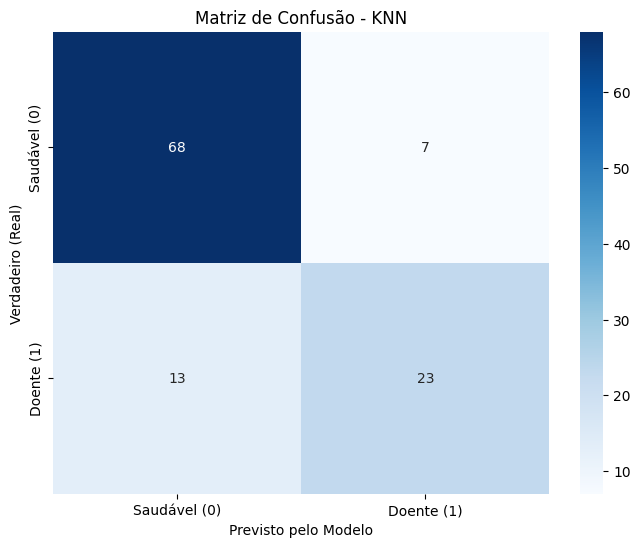

In [9]:
# Fazendo as Previsões
y_pred_best = best_svm.predict(X_test)
y_prob_best = best_svm.predict_proba(X_test)[:, 1]

# Métricas
acuracia_best = accuracy_score(y_test, y_pred_best)
precisao_best = precision_score(y_test, y_pred_best, average='macro')
recall_best   = recall_score(y_test, y_pred_best, average='macro')
f1_best       = f1_score(y_test, y_pred_best, average='macro')
mcc_best      = matthews_corrcoef(y_test, y_pred_best)

# O AUC binário recebe as classes reais e as probabilidades diretamente
auc = roc_auc_score(y_test, y_prob_best)

# Exibindo os Resultados
print("=== MÉTRICAS DE DESEMPENHO ===\n")
print(f"Acurácia: {acuracia_best:.4f}")
print(f"Precisão: {precisao_best:.4f}")
print(f"Recall:   {recall_best:.4f}")
print(f"F1-Score: {f1_best:.4f}")
print(f"MCC:      {mcc_best:.4f}")
print(f"AUC:      {auc:.4f}")
print("-" * 50)


# 5. Plotando a Matriz de Confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)

# Labels ajustados exclusivamente para as duas doenças
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Saudável (0)', 'Doente (1)'],
            yticklabels=['Saudável (0)', 'Doente (1)'])

plt.title('Matriz de Confusão - KNN')
plt.xlabel('Previsto pelo Modelo')
plt.ylabel('Verdadeiro (Real)')
plt.show()

## Salvar Resultados

In [10]:
import os
import pandas as pd

nome_modelo = 'svm'

# Caminhos dos arquivos
pasta_results = os.path.join(caminho, 'results')
os.makedirs(pasta_results, exist_ok=True)

arquivo_pred = os.path.join(pasta_results, 'predicoes.csv')
arquivo_proba = os.path.join(pasta_results, 'probabilidades.csv')

# Monta a linha com as predições de teste
linha_pred_teste = [nome_modelo, 'teste'] + list(y_pred_best)

# Salva adicionando no final do arquivo (mode='a')
pd.DataFrame([linha_pred_teste]).to_csv(
    arquivo_pred, mode='a', header=False, index=False
)

# Monta a linha com as probabilidades de teste 
probs = (
    y_prob_best[:, 1]
    if hasattr(y_prob_best, 'ndim') and y_prob_best.ndim == 2
    else y_prob_best
)
linha_proba_teste = [nome_modelo, 'teste'] + list(probs)

pd.DataFrame([linha_proba_teste]).to_csv(
    arquivo_proba, mode='a', header=False, index=False
)

print(f'Predições e probabilidades do modelo {nome_modelo} salvas com sucesso!')

Predições e probabilidades do modelo svm salvas com sucesso!
